<a href="https://colab.research.google.com/github/jigar-shroff/AiOnDigitalMediaResearch/blob/main/AIOnDigitalMediaResearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone "https://github.com/jigar-shroff/AiOnDigitalMediaResearch.git"

Cloning into 'AiOnDigitalMediaResearch'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 27 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 916.81 KiB | 15.54 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [4]:
aiFrame = pd.read_csv("AiOnDigitalMediaResearch/Global_AI_Content_Impact_Dataset.csv")
aiFrame

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


In [5]:
aiFrame.info() #no non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [6]:
aiFrame["Country"].value_counts()

,count
Country,
India,24
France,24
Japan,22
China,21
USA,21
South Korea,20
UK,20
Germany,17
Canada,16


Only Asia, N. Amer., Aus., and a small part of Eur. are represented w/ this data

In [7]:
#rename some columns

def removeParentheses(string):

  firstIndex = 0
  newString = string

  for r in range(len(string)):

    if(string[r] == "("):
      firstIndex = r
    elif(string[r] == ")"):
      newString = string[:firstIndex] + string[r+1:]

  return newString

print(aiFrame.columns)


for e in aiFrame.columns:

  aiFrame = aiFrame.rename(columns = {e: removeParentheses(e).strip()})

aiFrame


Index(['Country', 'Year', 'Industry', 'AI Adoption Rate (%)',
       'AI-Generated Content Volume (TBs per year)', 'Job Loss Due to AI (%)',
       'Revenue Increase Due to AI (%)', 'Human-AI Collaboration Rate (%)',
       'Top AI Tools Used', 'Regulation Status', 'Consumer Trust in AI (%)',
       'Market Share of AI Companies (%)'],
      dtype='object')


,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


In [8]:
sortedByYear = aiFrame.sort_values(by = "Year", ascending = True)
sortedByYear

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
12,France,2020,Marketing,71.00,77.53,17.41,12.56,31.57,Midjourney,Strict,56.93,38.36
26,USA,2020,Retail,26.12,73.78,21.51,22.63,65.41,Midjourney,Strict,44.56,3.46
25,France,2020,Automotive,79.59,20.37,39.06,44.06,83.18,Synthesia,Moderate,45.04,14.03
46,France,2020,Media,20.47,1.61,2.43,31.04,52.49,Stable Diffusion,Strict,35.80,24.29
51,South Korea,2020,Automotive,30.94,82.97,37.08,60.61,56.01,Bard,Lenient,85.10,38.38
...,...,...,...,...,...,...,...,...,...,...,...,...
133,China,2025,Gaming,70.04,66.60,29.79,23.17,58.46,Bard,Moderate,41.08,8.39
143,India,2025,Retail,76.35,78.99,3.82,0.73,70.78,Stable Diffusion,Lenient,70.39,45.49
194,France,2025,Retail,29.61,59.56,24.68,46.92,57.21,DALL-E,Moderate,31.70,28.90
192,Canada,2025,Marketing,78.43,84.82,26.41,4.72,33.28,Synthesia,Moderate,64.49,45.04


In [9]:
#Figure out consumer confidence over last few years

countries = sortedByYear.groupby("Country")
usa = countries.get_group("USA")
usa

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
26,USA,2020,Retail,26.12,73.78,21.51,22.63,65.41,Midjourney,Strict,44.56,3.46
111,USA,2020,Media,27.50,23.67,2.21,56.52,60.77,Claude,Strict,36.75,12.56
189,USA,2020,Finance,36.52,4.20,25.53,71.01,21.92,Bard,Moderate,84.90,29.93
126,USA,2021,Marketing,56.81,56.52,15.98,69.17,51.21,Midjourney,Lenient,54.41,20.22
90,USA,2021,Gaming,67.18,7.92,40.55,52.54,50.30,Synthesia,Moderate,73.15,8.66
47,USA,2021,Manufacturing,83.40,66.33,24.27,34.95,47.21,Claude,Moderate,47.81,47.40
5,USA,2021,Retail,66.95,47.72,0.86,27.58,64.42,ChatGPT,Lenient,68.14,8.09
179,USA,2021,Education,87.79,40.86,28.82,74.04,70.58,Stable Diffusion,Strict,60.03,12.22
146,USA,2021,Education,73.11,98.77,38.22,67.17,87.65,Synthesia,Lenient,31.54,31.14
38,USA,2022,Manufacturing,44.61,26.16,49.34,58.53,75.29,Stable Diffusion,Moderate,32.96,43.24


In [10]:
americaByYears = []

for r in range(2020, 2026, 1):
  americaByYears.append(usa.groupby("Year").get_group(r))



In [11]:
#the length of all the dataframes in the array are not equal to each other
#also there are duplicate industries??? Is that right??

In [12]:
usaMeans = [] #stores the mean of each year

for df in americaByYears:
  usaMeans.append(df["Consumer Trust in AI"].mean())

print(usaMeans)

[np.float64(55.403333333333336), np.float64(55.846666666666664), np.float64(44.92333333333334), np.float64(70.965), np.float64(60.99), np.float64(56.883333333333326)]


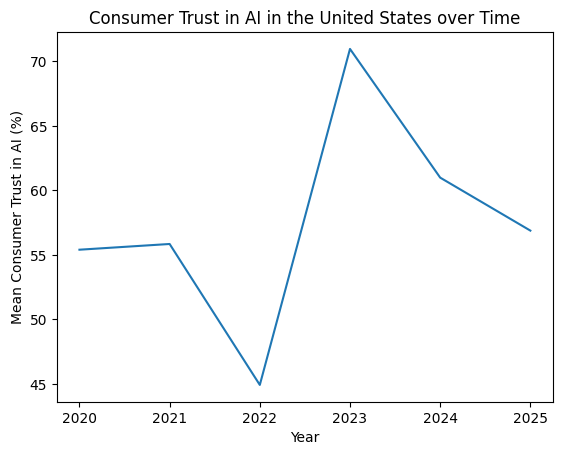

In [13]:
years = [2020, 2021, 2022, 2023, 2024, 2025]

plt.plot(years, usaMeans)

plt.title("Consumer Trust in AI in the United States over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

[np.float64(58.791999999999994), np.float64(54.16), np.float64(72.87), np.float64(39.63), np.float64(58.078333333333326), np.float64(62.73375)]


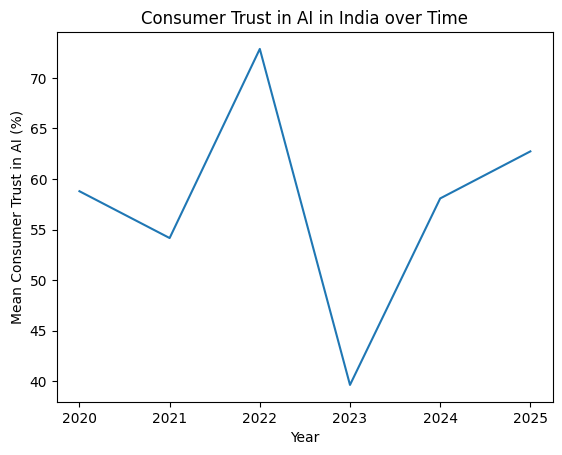

In [14]:
indiaByYears = []

for r in range(2020, 2026, 1):
  indiaByYears.append(countries.get_group("India").groupby("Year").get_group(r))

indiaMeans = []

for df in indiaByYears:
  indiaMeans.append(df["Consumer Trust in AI"].mean())

print(indiaMeans)

plt.plot(years, indiaMeans)
plt.title("Consumer Trust in AI in India over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

In [15]:
indiaByYears[0]

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
74,India,2020,Media,43.55,14.89,13.87,41.09,37.81,ChatGPT,Moderate,86.44,35.30
158,India,2020,Retail,93.72,27.55,48.33,31.86,75.36,Bard,Moderate,73.23,9.67
154,India,2020,Education,70.48,19.97,33.75,15.07,64.12,Stable Diffusion,Moderate,48.13,40.32
147,India,2020,Automotive,64.03,5.21,41.36,53.59,23.62,DALL-E,Moderate,37.89,34.26
186,India,2020,Automotive,80.04,36.49,29.72,76.74,69.01,ChatGPT,Moderate,48.27,44.80


In [16]:
sortedByYear["Country"].value_counts()

,count
Country,
France,24
India,24
Japan,22
USA,21
China,21
South Korea,20
UK,20
Germany,17
Canada,16


In [17]:
india = countries.get_group("India")
france = countries.get_group("France")
japan = countries.get_group("Japan")
china = countries.get_group("China")
sKorea = countries.get_group("South Korea")
uk = countries.get_group("UK")
germany = countries.get_group("Germany")
canada = countries.get_group("Canada")
australia = countries.get_group("Australia")

In [18]:
franceByYears = []

for r in range(2020, 2026, 1):
  franceByYears.append(france.groupby("Year").get_group(r))

japanByYears = []

for r in range(2020, 2026, 1):
  japanByYears.append(japan.groupby("Year").get_group(r))

chinaByYears = []

for r in range(2020, 2026, 1):
  chinaByYears.append(china.groupby("Year").get_group(r))

sKoreaByYears = []

for r in range(2020, 2026, 1):
  sKoreaByYears.append(sKorea.groupby("Year").get_group(r))

ukByYears = []

for r in range(2020, 2026, 1):
  ukByYears.append(uk.groupby("Year").get_group(r))

germanyByYears = []

for r in range(2020, 2026, 1):
  try:
    germanyByYears.append(germany.groupby("Year").get_group(r))
  except KeyError:
    continue

canadaByYears = []

for r in range(2020, 2026, 1):
  try:
    canadaByYears.append(canada.groupby("Year").get_group(r))
  except KeyError:
    continue

australiaByYears = []

for r in range(2020, 2026, 1):
  australiaByYears.append(australia.groupby("Year").get_group(r))

In [19]:
franceByYears[0]

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
12,France,2020,Marketing,71.00,77.53,17.41,12.56,31.57,Midjourney,Strict,56.93,38.36
25,France,2020,Automotive,79.59,20.37,39.06,44.06,83.18,Synthesia,Moderate,45.04,14.03
46,France,2020,Media,20.47,1.61,2.43,31.04,52.49,Stable Diffusion,Strict,35.80,24.29
54,France,2020,Manufacturing,93.16,50.91,36.57,35.31,78.29,ChatGPT,Lenient,65.04,9.04
134,France,2020,Legal,64.43,41.41,38.39,19.26,88.29,DALL-E,Strict,45.13,6.24
170,France,2020,Media,55.19,41.06,29.26,51.90,49.04,ChatGPT,Moderate,50.12,46.08


Why's some data not only recorded twice, but also the data within is actually DIFFERENT?

How can the French media industry in 2020 both have a 20.47% adoption rate, and a 55.19% adoption rate

It has to be that some of the industries are visual and the others are text based, but why's it so vague??

In [20]:
franceMeans = {2020: [], 2021: [], 2022: [], 2023: [], 2024: [], 2025: []}
japanMeans ={2020: [], 2021: [], 2022: [], 2023: [], 2024: [], 2025: []}
chinaMeans = {2020: [], 2021: [], 2022: [], 2023: [], 2024: [], 2025: []}
sKoreaMeans = {2020: [], 2021: [], 2022: [], 2023: [], 2024: [], 2025: []}
ukMeans = {2020: [], 2021: [], 2022: [], 2023: [], 2024: [], 2025: []}
germanyMeans = {2020: [], 2021: [], 2022: [], 2023: [], 2024: [], 2025: []}
canadaMeans = {2020: [], 2021: [], 2022: [], 2023: [], 2024: [], 2025: []}
australiaMeans = {2020: [], 2021: [], 2022: [], 2023: [], 2024: [], 2025: []}

for df in franceByYears:
  franceMeans[df["Year"].values[0]].append(df["Consumer Trust in AI"].mean())

for df in japanByYears:
  japanMeans[df["Year"].values[0]].append(df["Consumer Trust in AI"].mean())

for df in chinaByYears:
  chinaMeans[df["Year"].values[0]].append(df["Consumer Trust in AI"].mean())

for df in sKoreaByYears:
  sKoreaMeans[df["Year"].values[0]].append(df["Consumer Trust in AI"].mean())

for df in ukByYears:
  ukMeans[df["Year"].values[0]].append(df["Consumer Trust in AI"].mean())

for df in germanyByYears:
  germanyMeans[df["Year"].values[0]].append(df["Consumer Trust in AI"].mean())

for df in canadaByYears:
  canadaMeans[df["Year"].values[0]].append(df["Consumer Trust in AI"].mean())

for df in australiaByYears:
  australiaMeans[df["Year"].values[0]].append(df["Consumer Trust in AI"].mean())


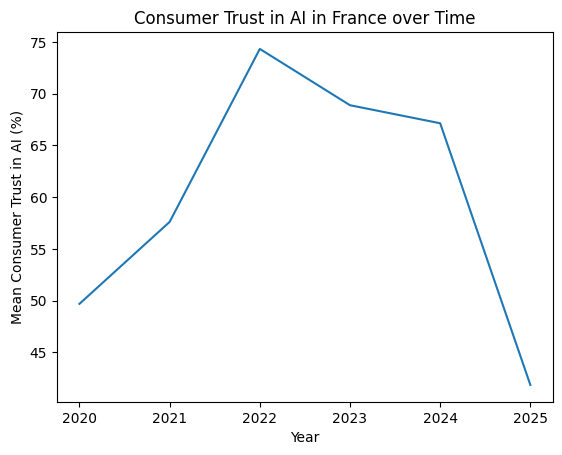

In [21]:
plt.plot(franceMeans.keys(), franceMeans.values())

plt.title("Consumer Trust in AI in France over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

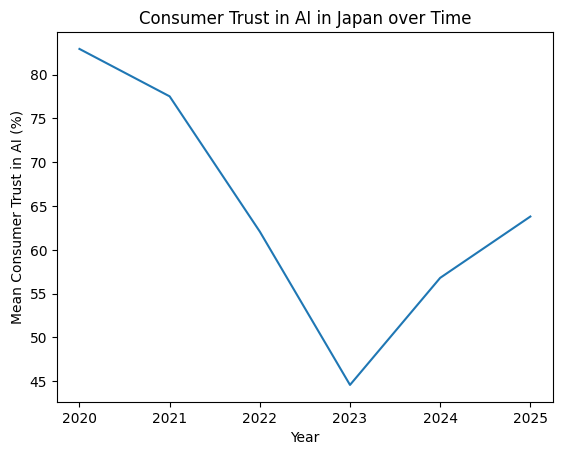

In [22]:
plt.plot(japanMeans.keys(), japanMeans.values())

plt.title("Consumer Trust in AI in Japan over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

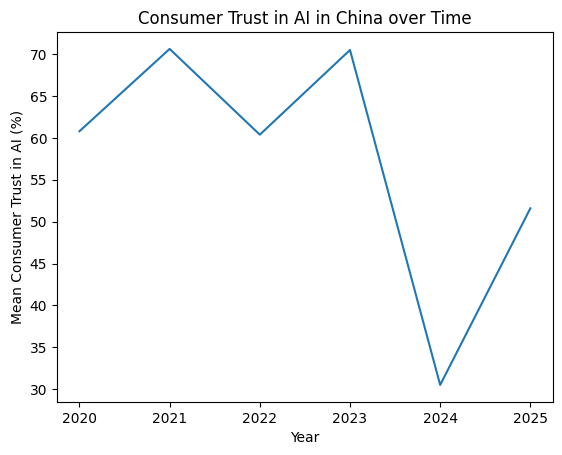

In [23]:
plt.plot(chinaMeans.keys(), chinaMeans.values())

plt.title("Consumer Trust in AI in China over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

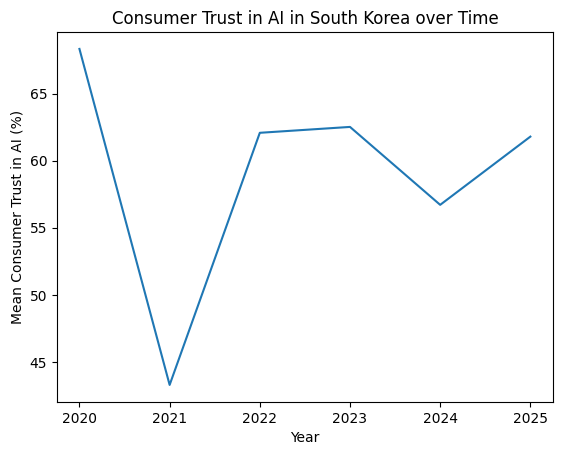

In [24]:
plt.plot(sKoreaMeans.keys(), sKoreaMeans.values())

plt.title("Consumer Trust in AI in South Korea over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

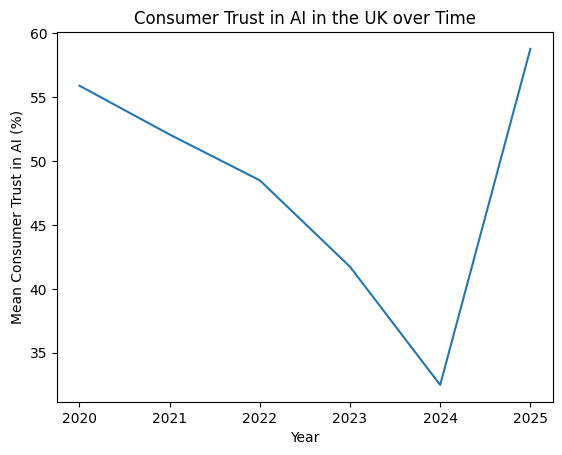

In [25]:
plt.plot(ukMeans.keys(), ukMeans.values())

plt.title("Consumer Trust in AI in the UK over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

In [26]:
for r in range(len(germanyByYears)):
  print(germanyByYears[r]["Year"])

88     2020
159    2020
141    2020
135    2020
196    2020
Name: Year, dtype: int64
62     2021
39     2021
181    2021
184    2021
195    2021
Name: Year, dtype: int64
27    2022
16    2022
Name: Year, dtype: int64
98     2023
118    2023
56     2023
167    2023
Name: Year, dtype: int64
123    2024
Name: Year, dtype: int64


In [27]:
germanyMeans.pop(2025)

[]

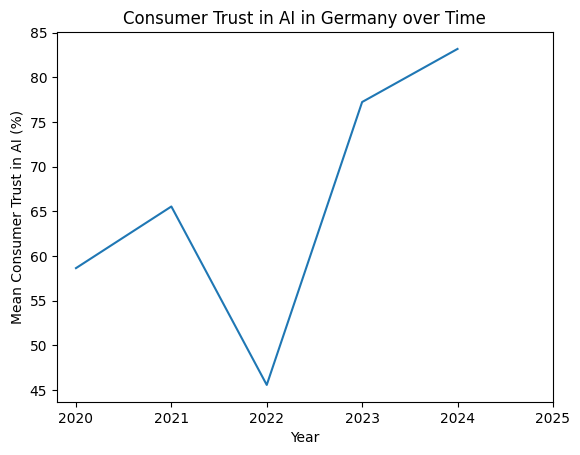

In [28]:
plt.plot(germanyMeans.keys(), germanyMeans.values())

#plt.plot(germanyMeans.keys(), germanyMeans.values())
plt.title("Consumer Trust in AI in Germany over Time")
plt.xlabel("Year")
plt.xticks([2020, 2021, 2022, 2023, 2024, 2025])
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

In [29]:
for r in range(len(canadaByYears)):
  print(canadaByYears[r]["Year"])

60     2020
163    2020
191    2020
182    2020
169    2020
Name: Year, dtype: int64
112    2021
Name: Year, dtype: int64
174    2022
116    2022
104    2022
30     2022
Name: Year, dtype: int64
48     2023
156    2023
Name: Year, dtype: int64
120    2025
20     2025
8      2025
192    2025
Name: Year, dtype: int64


In [30]:
print(canadaMeans)
canadaMeans.pop(2024)
print(canadaMeans)

{2020: [np.float64(50.596000000000004)], 2021: [np.float64(89.07)], 2022: [np.float64(66.09500000000001)], 2023: [np.float64(78.745)], 2024: [], 2025: [np.float64(57.620000000000005)]}
{2020: [np.float64(50.596000000000004)], 2021: [np.float64(89.07)], 2022: [np.float64(66.09500000000001)], 2023: [np.float64(78.745)], 2025: [np.float64(57.620000000000005)]}


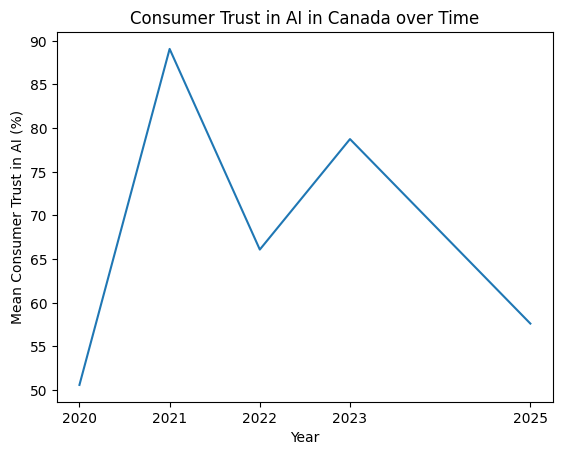

In [31]:
plt.plot(canadaMeans.keys(), canadaMeans.values())
plt.title("Consumer Trust in AI in Canada over Time")
plt.xlabel("Year")
plt.xticks([2020, 2021, 2022, 2023, 2025])

plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

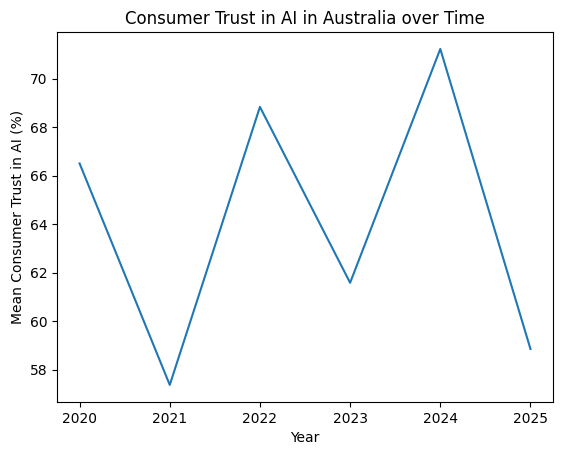

In [32]:
plt.plot(australiaMeans.keys(), australiaMeans.values())

plt.title("Consumer Trust in AI in Australia over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

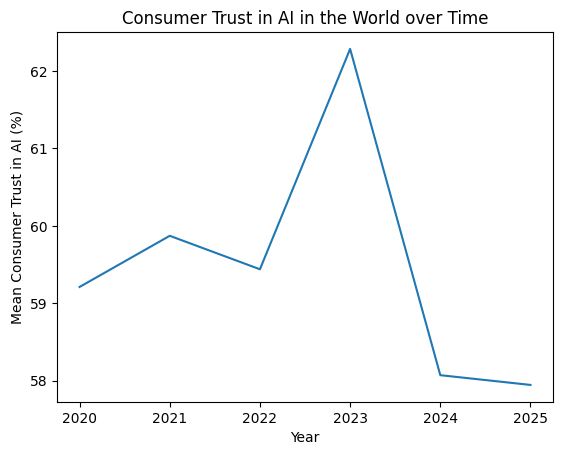

In [33]:
groupedByYears = sortedByYear.groupby("Year")

plt.plot(years, [groupedByYears.get_group(2020)["Consumer Trust in AI"].mean(), groupedByYears.get_group(2021)["Consumer Trust in AI"].mean(), groupedByYears.get_group(2022)["Consumer Trust in AI"].mean(), groupedByYears.get_group(2023)["Consumer Trust in AI"].mean(), groupedByYears.get_group(2024)["Consumer Trust in AI"].mean(), groupedByYears.get_group(2025)["Consumer Trust in AI"].mean()])

plt.title("Consumer Trust in AI in the World over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

Try to find a relatinship b/t regulation levels over time

In [34]:
regulationsEncoded = aiFrame.copy()

for r in range(len(regulationsEncoded["Regulation Status"])):

  match regulationsEncoded["Regulation Status"][r]:

    case "Lenient":
      regulationsEncoded["Regulation Status"][r] = 1
    case "Moderate":
      regulationsEncoded["Regulation Status"][r] = 2
    case "Strict":
      regulationsEncoded["Regulation Status"][r] = 3

regulationsEncoded["Regulation Status"].value_counts()


/tmp/ipykernel_978/662180705.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  regulationsEncoded["Regulation Status"][r] = 3
/tmp/ipykernel_978/662180705.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

,count
Regulation Status,
2,76
1,63
3,61


In [35]:
yearGroups = regulationsEncoded.groupby("Regulation Status")["Year"]
strict = yearGroups.get_group(3)
moderate = yearGroups.get_group(2)
lenient = yearGroups.get_group(1)

print(strict.value_counts())

Year
2020    14
2022    11
2024    11
2023    10
2025     8
2021     7
Name: count, dtype: int64


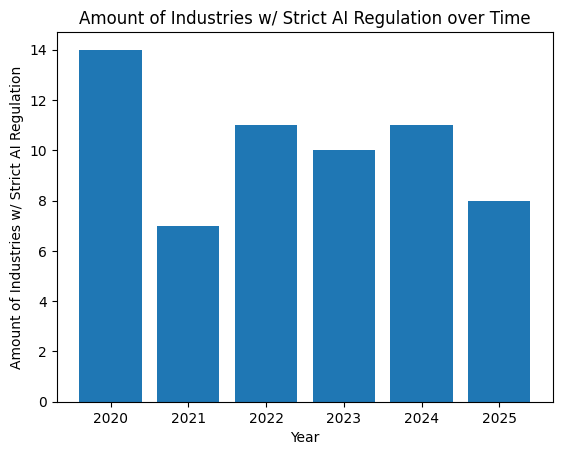

In [36]:
#strict bar plot

plt.bar(strict.value_counts().index, strict.value_counts().values)

plt.xlabel("Year")
plt.ylabel("Amount of Industries w/ Strict AI Regulation")
plt.title("Amount of Industries w/ Strict AI Regulation over Time")

plt.show()

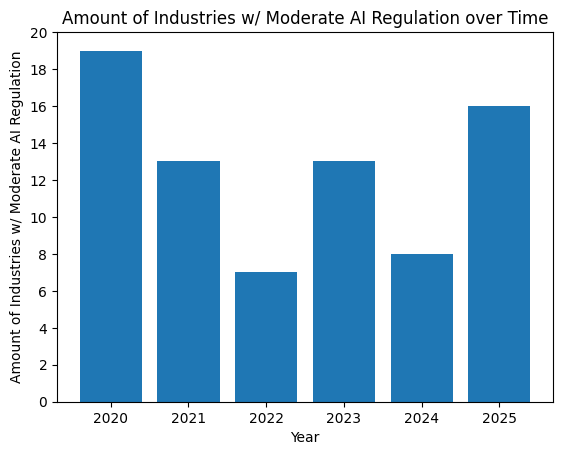

In [37]:
plt.bar(moderate.value_counts().index, moderate.value_counts().values)

plt.xlabel("Year")
plt.ylabel("Amount of Industries w/ Moderate AI Regulation")
plt.yticks(range(0, 21, 2))
plt.title("Amount of Industries w/ Moderate AI Regulation over Time")

plt.show()

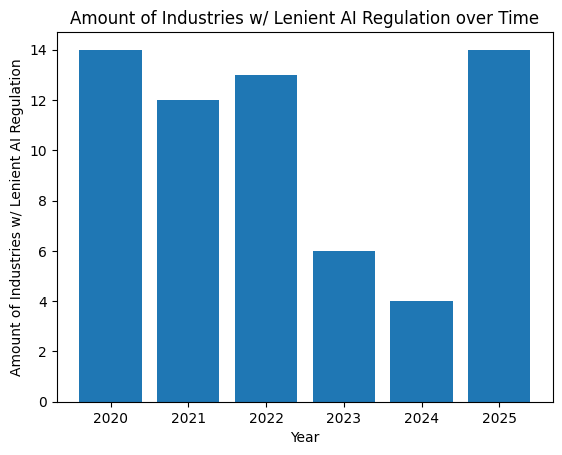

In [38]:
plt.bar(lenient.value_counts().index, lenient.value_counts().values)

plt.xlabel("Year")
plt.ylabel("Amount of Industries w/ Lenient AI Regulation")
plt.title("Amount of Industries w/ Lenient AI Regulation over Time")

plt.show()

In [39]:
years = aiFrame.groupby("Year")
y2020 = years.get_group(2020)
y2021 = years.get_group(2021)
y2022 = years.get_group(2022)
y2023 = years.get_group(2023)
y2024 = years.get_group(2024)
y2025 = years.get_group(2025)

y2020["Regulation Status"].value_counts()

,count
Regulation Status,
Moderate,19
Strict,14
Lenient,14


In [40]:
aiFrame

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


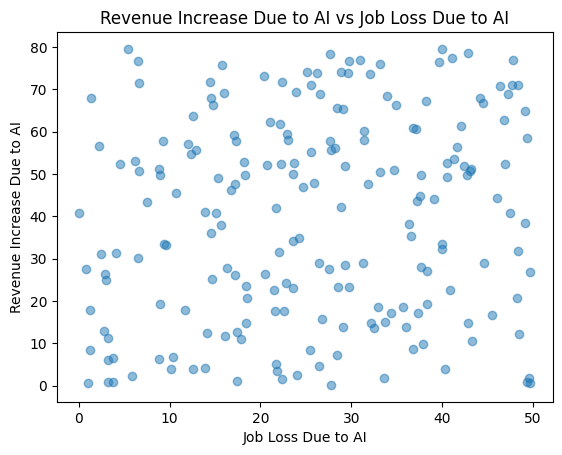

In [41]:
plt.scatter(aiFrame["Job Loss Due to AI"], aiFrame["Revenue Increase Due to AI"], alpha = 0.5)

plt.title("Revenue Increase Due to AI vs Job Loss Due to AI")
plt.xlabel("Job Loss Due to AI")
plt.ylabel("Revenue Increase Due to AI")
plt.show()

In [42]:
aiFrame["Top AI Tools Used"].value_counts()

,count
Top AI Tools Used,
Midjourney,37
Claude,31
ChatGPT,31
Stable Diffusion,27
DALL-E,26
Bard,24
Synthesia,24


In [43]:
modelGroups = aiFrame.groupby("Top AI Tools Used")

chatGPT = modelGroups.get_group("ChatGPT")
midjourney = modelGroups.get_group("Midjourney")
stableDiffusion = modelGroups.get_group("Stable Diffusion")
dallE = modelGroups.get_group("DALL-E")
gemini = modelGroups.get_group("Bard")
synthesia = modelGroups.get_group("Synthesia")

In [44]:
synthesia

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
10,USA,2023,Retail,11.94,91.59,26.28,73.93,57.55,Synthesia,Moderate,65.79,29.30
17,UK,2025,Manufacturing,64.87,49.04,36.31,38.16,82.41,Synthesia,Lenient,78.14,20.54
23,France,2022,Media,49.97,5.59,22.61,17.55,34.97,Synthesia,Lenient,78.71,27.60
24,France,2023,Media,88.41,5.34,36.07,13.78,36.24,Synthesia,Moderate,58.85,35.86
25,France,2020,Automotive,79.59,20.37,39.06,44.06,83.18,Synthesia,Moderate,45.04,14.03
28,France,2021,Media,42.53,44.38,8.99,49.69,47.11,Synthesia,Moderate,55.15,46.58
34,India,2025,Gaming,16.79,8.50,28.43,65.47,23.38,Synthesia,Moderate,59.92,16.40
66,UK,2020,Legal,50.34,50.70,1.04,0.58,68.07,Synthesia,Strict,37.36,28.87
82,UK,2022,Automotive,80.83,67.55,42.39,51.87,74.39,Synthesia,Strict,33.56,21.66
86,India,2024,Marketing,55.30,67.76,3.21,11.15,48.72,Synthesia,Strict,58.79,45.09


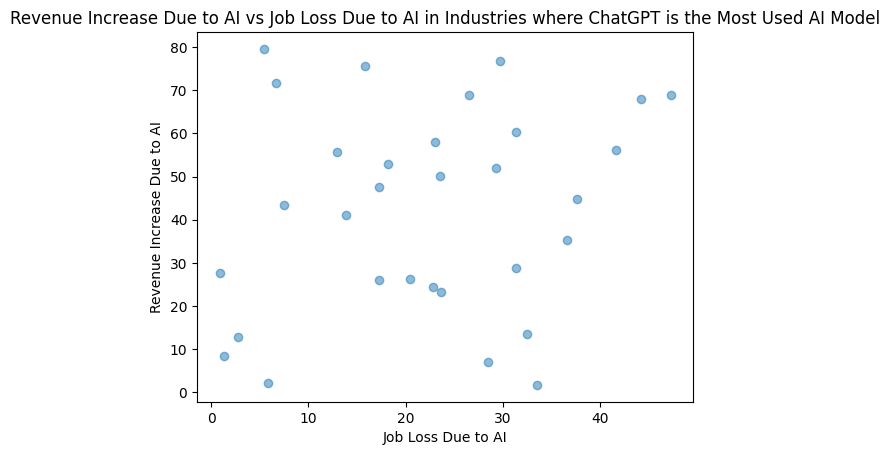

In [45]:
plt.scatter(chatGPT["Job Loss Due to AI"], chatGPT["Revenue Increase Due to AI"], alpha = 0.5)

plt.title("Revenue Increase Due to AI vs Job Loss Due to AI in Industries where ChatGPT is the Most Used AI Model")
plt.xlabel("Job Loss Due to AI")
plt.ylabel("Revenue Increase Due to AI")
plt.show()

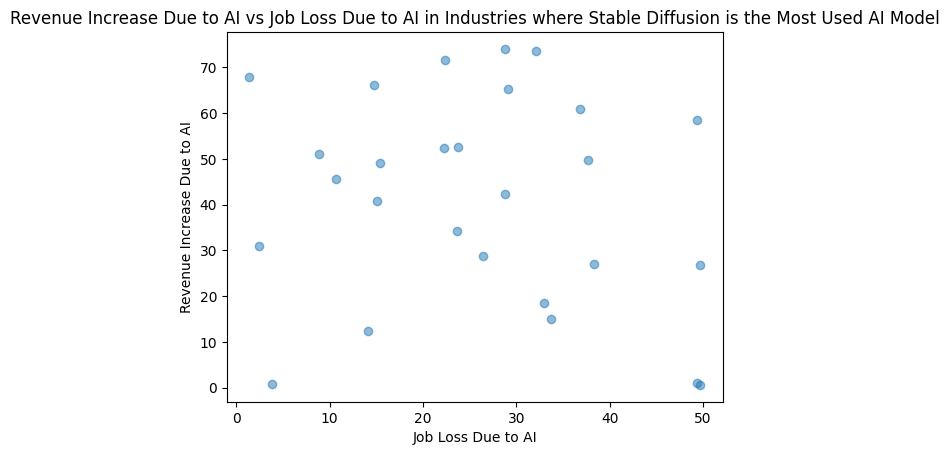

In [46]:
plt.scatter(stableDiffusion["Job Loss Due to AI"], stableDiffusion["Revenue Increase Due to AI"], alpha = 0.5)

plt.title("Revenue Increase Due to AI vs Job Loss Due to AI in Industries where Stable Diffusion is the Most Used AI Model")
plt.xlabel("Job Loss Due to AI")
plt.ylabel("Revenue Increase Due to AI")
plt.show()

In [47]:
chatGPT["Country"].value_counts()

,count
Country,
France,5
Australia,4
South Korea,4
UK,3
Germany,3
India,3
China,3
Japan,3
USA,2


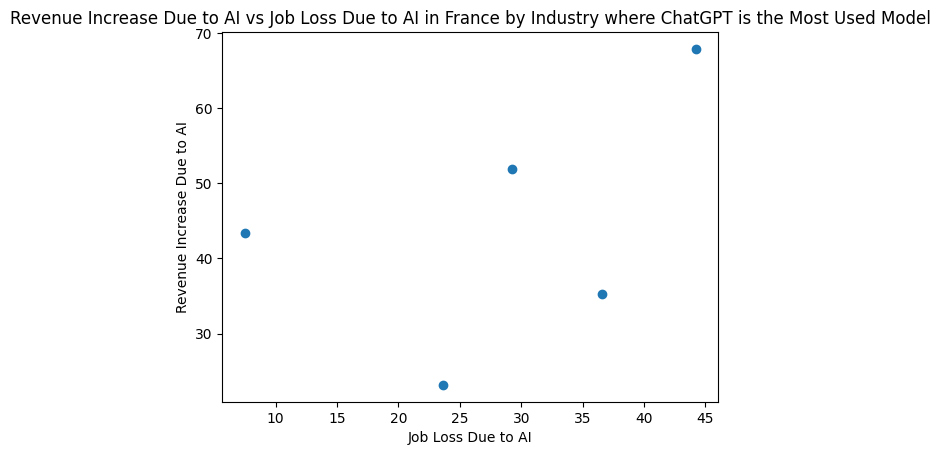

In [48]:
frGPT = chatGPT.groupby("Country").get_group("France")

plt.scatter(frGPT["Job Loss Due to AI"], frGPT["Revenue Increase Due to AI"])

plt.title("Revenue Increase Due to AI vs Job Loss Due to AI in France by Industry where ChatGPT is the Most Used Model")
plt.xlabel("Job Loss Due to AI")
plt.ylabel("Revenue Increase Due to AI")
plt.show()

vaguely positive but also nowhere near enough data

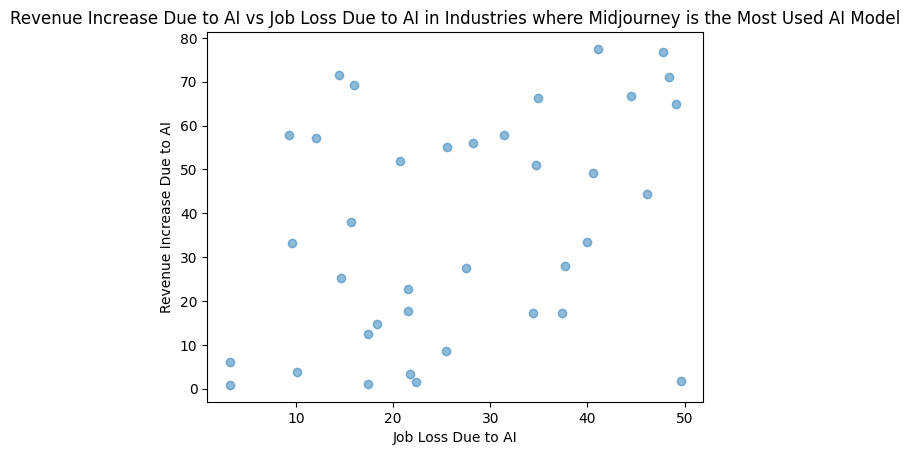

In [49]:
plt.scatter(midjourney["Job Loss Due to AI"], midjourney["Revenue Increase Due to AI"], alpha = 0.5)

plt.title("Revenue Increase Due to AI vs Job Loss Due to AI in Industries where Midjourney is the Most Used AI Model")
plt.xlabel("Job Loss Due to AI")
plt.ylabel("Revenue Increase Due to AI")
plt.show()

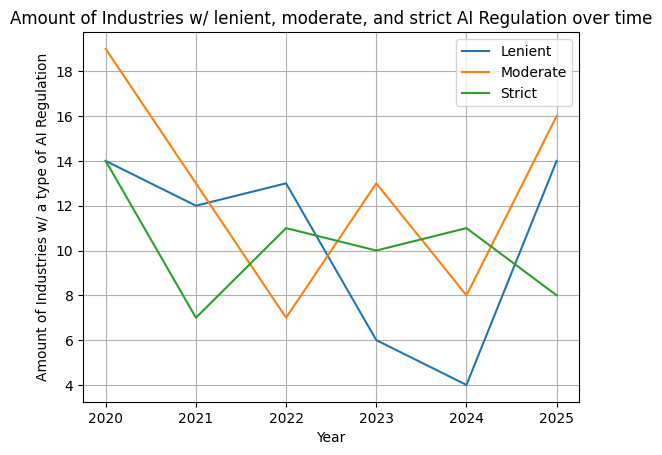

In [50]:
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Regulation Status"].value_counts()["Lenient"], y2021["Regulation Status"].value_counts()["Lenient"], y2022["Regulation Status"].value_counts()["Lenient"], y2023["Regulation Status"].value_counts()["Lenient"], y2024["Regulation Status"].value_counts()["Lenient"], y2025["Regulation Status"].value_counts()["Lenient"]])
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Regulation Status"].value_counts()["Moderate"], y2021["Regulation Status"].value_counts()["Moderate"], y2022["Regulation Status"].value_counts()["Moderate"], y2023["Regulation Status"].value_counts()["Moderate"], y2024["Regulation Status"].value_counts()["Moderate"], y2025["Regulation Status"].value_counts()["Moderate"]])
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Regulation Status"].value_counts()["Strict"], y2021["Regulation Status"].value_counts()["Strict"], y2022["Regulation Status"].value_counts()["Strict"], y2023["Regulation Status"].value_counts()["Strict"], y2024["Regulation Status"].value_counts()["Strict"], y2025["Regulation Status"].value_counts()["Strict"]])

plt.legend(["Lenient", "Moderate", "Strict"])
plt.xlabel("Year")
plt.ylabel("Amount of Industries w/ a type of AI Regulation")
plt.title("Amount of Industries w/ lenient, moderate, and strict AI Regulation over time")
plt.grid()

plt.show()

In [51]:
y2020["Regulation Status"].value_counts().sum()

np.int64(47)

In [52]:
aiFrame

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


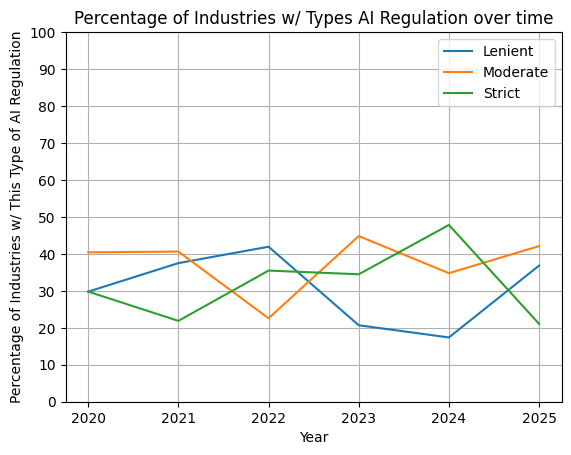

In [53]:

lenientPercentages = [y2020["Regulation Status"].value_counts()["Lenient"]/y2020["Regulation Status"].value_counts().sum(), y2021["Regulation Status"].value_counts()["Lenient"]/y2021["Regulation Status"].value_counts().sum(), y2022["Regulation Status"].value_counts()["Lenient"]/y2022["Regulation Status"].value_counts().sum(), y2023["Regulation Status"].value_counts()["Lenient"]/y2023["Regulation Status"].value_counts().sum(), y2024["Regulation Status"].value_counts()["Lenient"]/y2024["Regulation Status"].value_counts().sum(), y2025["Regulation Status"].value_counts()["Lenient"]/y2025["Regulation Status"].value_counts().sum()]
moderatePercentages = [y2020["Regulation Status"].value_counts()["Moderate"]/y2020["Regulation Status"].value_counts().sum(), y2021["Regulation Status"].value_counts()["Moderate"]/y2021["Regulation Status"].value_counts().sum(), y2022["Regulation Status"].value_counts()["Moderate"]/y2022["Regulation Status"].value_counts().sum(), y2023["Regulation Status"].value_counts()["Moderate"]/y2023["Regulation Status"].value_counts().sum(), y2024["Regulation Status"].value_counts()["Moderate"]/y2024["Regulation Status"].value_counts().sum(), y2025["Regulation Status"].value_counts()["Moderate"]/y2025["Regulation Status"].value_counts().sum()]
strictPercentages = [y2020["Regulation Status"].value_counts()["Strict"]/y2020["Regulation Status"].value_counts().sum(), y2021["Regulation Status"].value_counts()["Strict"]/y2021["Regulation Status"].value_counts().sum(), y2022["Regulation Status"].value_counts()["Strict"]/y2022["Regulation Status"].value_counts().sum(), y2023["Regulation Status"].value_counts()["Strict"]/y2023["Regulation Status"].value_counts().sum(), y2024["Regulation Status"].value_counts()["Strict"]/y2024["Regulation Status"].value_counts().sum(), y2025["Regulation Status"].value_counts()["Strict"]/y2025["Regulation Status"].value_counts().sum()]

for r in range(len(lenientPercentages)):
  lenientPercentages[r] *= 100
  moderatePercentages[r] *= 100
  strictPercentages[r] *= 100

plt.plot([2020, 2021, 2022, 2023, 2024, 2025], lenientPercentages)
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], moderatePercentages)
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], strictPercentages)

plt.legend(["Lenient", "Moderate", "Strict"])
plt.xlabel("Year")
plt.ylabel("Percentage of Industries w/ This Type of AI Regulation")

plt.yticks(range(0, 101, 10))

plt.title("Percentage of Industries w/ Types AI Regulation over time")
plt.grid()

plt.show()

In [54]:
aiFrame

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


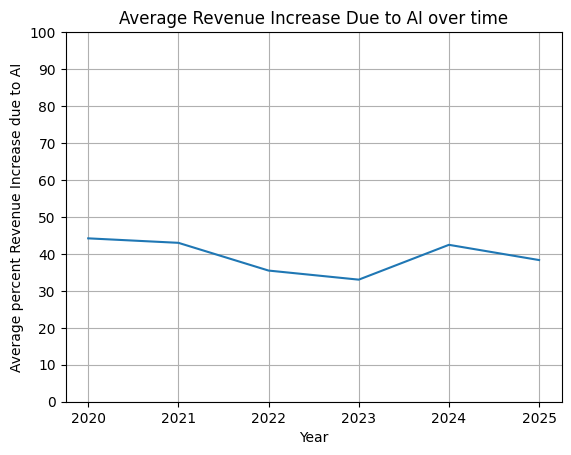

In [55]:
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Revenue Increase Due to AI"].mean(), y2021["Revenue Increase Due to AI"].mean(), y2022["Revenue Increase Due to AI"].mean(), y2023["Revenue Increase Due to AI"].mean(), y2024["Revenue Increase Due to AI"].mean(), y2025["Revenue Increase Due to AI"].mean()])

plt.xlabel("Year")
plt.ylabel("Average percent Revenue Increase due to AI")
plt.title("Average Revenue Increase Due to AI over time")
plt.grid()
plt.yticks(range(0, 101, 10))
plt.show()

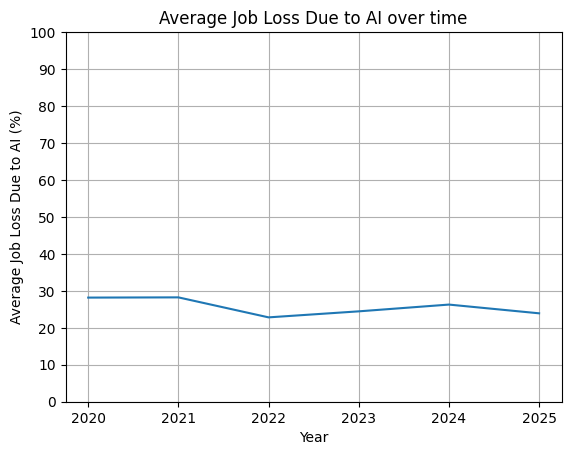

In [56]:
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Job Loss Due to AI"].mean(), y2021["Job Loss Due to AI"].mean(), y2022["Job Loss Due to AI"].mean(), y2023["Job Loss Due to AI"].mean(), y2024["Job Loss Due to AI"].mean(), y2025["Job Loss Due to AI"].mean()])

plt.xlabel("Year")
plt.ylabel("Average Job Loss Due to AI (%)")
plt.title("Average Job Loss Due to AI over time")
plt.grid()
plt.yticks(range(0, 101, 10))

plt.show()

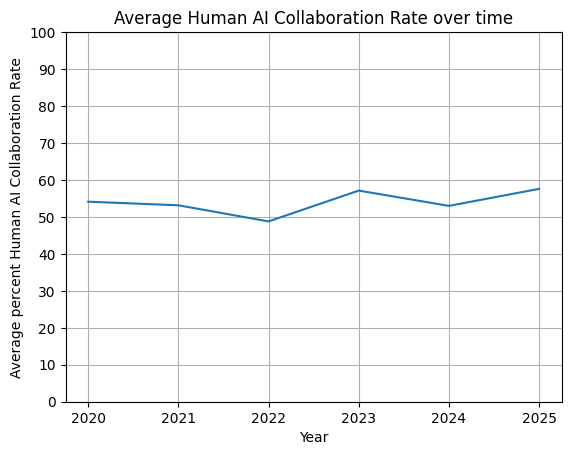

In [57]:
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Human-AI Collaboration Rate"].mean(), y2021["Human-AI Collaboration Rate"].mean(), y2022["Human-AI Collaboration Rate"].mean(), y2023["Human-AI Collaboration Rate"].mean(), y2024["Human-AI Collaboration Rate"].mean(), y2025["Human-AI Collaboration Rate"].mean()])

plt.xlabel("Year")
plt.ylabel("Average percent Human AI Collaboration Rate")
plt.title("Average Human AI Collaboration Rate over time")
plt.grid()
plt.yticks(range(0, 101, 10))
plt.show()

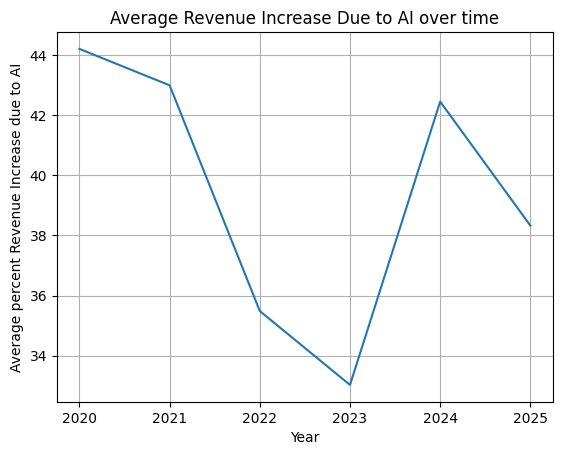

In [58]:
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Revenue Increase Due to AI"].mean(), y2021["Revenue Increase Due to AI"].mean(), y2022["Revenue Increase Due to AI"].mean(), y2023["Revenue Increase Due to AI"].mean(), y2024["Revenue Increase Due to AI"].mean(), y2025["Revenue Increase Due to AI"].mean()])

plt.xlabel("Year")
plt.ylabel("Average percent Revenue Increase due to AI")
plt.title("Average Revenue Increase Due to AI over time")
plt.grid()
# plt.yticks(range(0, 101, 10))
plt.show()

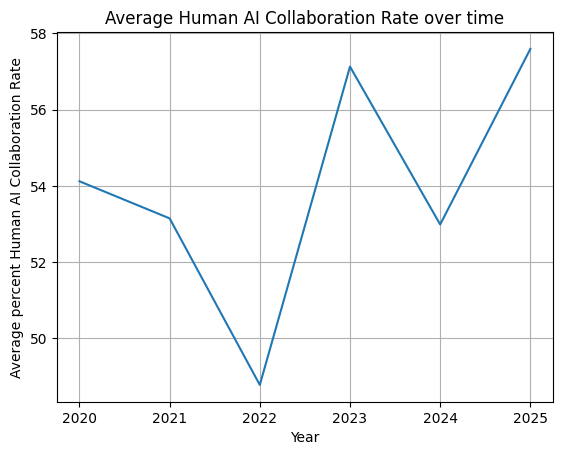

In [59]:
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Human-AI Collaboration Rate"].mean(), y2021["Human-AI Collaboration Rate"].mean(), y2022["Human-AI Collaboration Rate"].mean(), y2023["Human-AI Collaboration Rate"].mean(), y2024["Human-AI Collaboration Rate"].mean(), y2025["Human-AI Collaboration Rate"].mean()])

plt.xlabel("Year")
plt.ylabel("Average percent Human AI Collaboration Rate")
plt.title("Average Human AI Collaboration Rate over time")
plt.grid()
# plt.yticks(range(0, 101, 10))
plt.show()

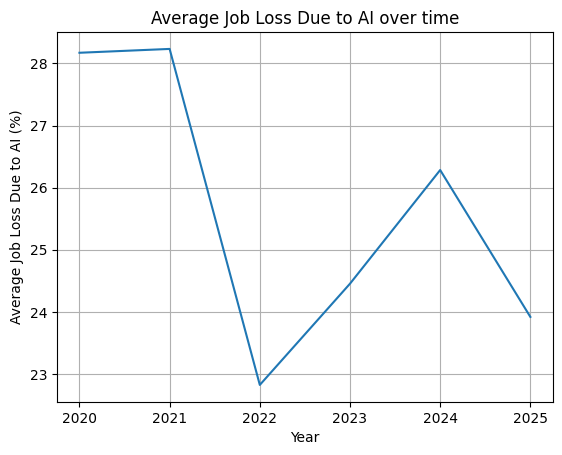

In [60]:
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["Job Loss Due to AI"].mean(), y2021["Job Loss Due to AI"].mean(), y2022["Job Loss Due to AI"].mean(), y2023["Job Loss Due to AI"].mean(), y2024["Job Loss Due to AI"].mean(), y2025["Job Loss Due to AI"].mean()])

plt.xlabel("Year")
plt.ylabel("Average Job Loss Due to AI (%)")
plt.title("Average Job Loss Due to AI over time")
plt.grid()
# plt.yticks(range(0, 101, 10))

plt.show()

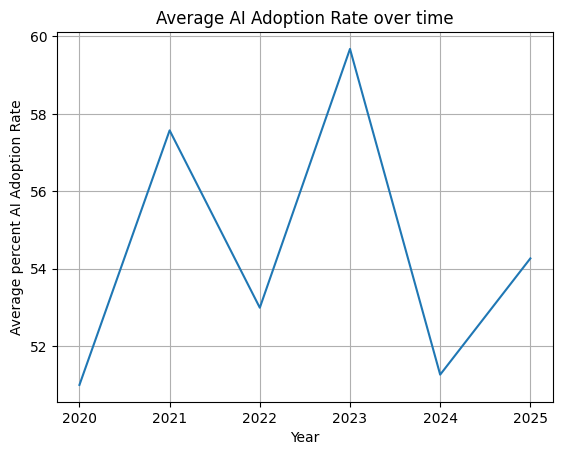

In [61]:
plt.plot([2020, 2021, 2022, 2023, 2024, 2025], [y2020["AI Adoption Rate"].mean(), y2021["AI Adoption Rate"].mean(), y2022["AI Adoption Rate"].mean(), y2023["AI Adoption Rate"].mean(), y2024["AI Adoption Rate"].mean(), y2025["AI Adoption Rate"].mean()])

plt.xlabel("Year")
plt.ylabel("Average percent AI Adoption Rate")
plt.title("Average AI Adoption Rate over time")
plt.grid()
#plt.yticks(range(0, 101, 10))
plt.show()

In situations where there is high job loss due to AI/"high human-AI collaboration," is there net revenue gain afterwards?

In [62]:
aiFrame

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


In [67]:
aiFrame["Job Loss Due to AI"]

,Job Loss Due to AI
0,16.77
1,46.89
2,10.66
3,27.70
4,17.45
...,...
195,48.47
196,27.62
197,39.94
198,33.21


In [64]:
print(aiFrame["Job Loss Due to AI"].mean())

25.788249999999998


In [76]:
meanJobLoss20 = y2020["Job Loss Due to AI"].mean()
meanJobLoss21 = y2021["Job Loss Due to AI"].mean()
meanJobLoss22 = y2022["Job Loss Due to AI"].mean()
meanJobLoss23 = y2023["Job Loss Due to AI"].mean()
meanJobLoss24 = y2024["Job Loss Due to AI"].mean()
meanJobLoss25 = y2025["Job Loss Due to AI"].mean()

meanJobLossDict = {"2020": meanJobLoss20, "2021": meanJobLoss21, "2022": meanJobLoss22, "2023": meanJobLoss23, "2024": meanJobLoss24, "2025": meanJobLoss25}

higherOrLowerJobLoss = {"Higher than Average Job Loss for that Year": []}

arrayRep = aiFrame.values

for r in range(len(arrayRep)):

  if arrayRep[r][5] > meanJobLossDict[str(arrayRep[r][1])]:
    higherOrLowerJobLoss["Higher than Average Job Loss for that Year"].append(True)
  else:
    higherOrLowerJobLoss["Higher than Average Job Loss for that Year"].append(False)

higherOrLowerJobLoss

newAIFrame = aiFrame.copy()
newAIFrame["Higher than Average Job Loss for that Year"] = higherOrLowerJobLoss["Higher than Average Job Loss for that Year"]
newAIFrame

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies,Higher than Average Job Loss for that Year
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73,False
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02,True
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76,False
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93,False
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35,True
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73,False
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62,True
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11,True


In [78]:
for e in meanJobLossDict:
  print(e, meanJobLossDict[e])

2020 28.171914893617014
2021 28.233749999999997
2022 22.823225806451614
2023 24.453448275862073
2024 26.283478260869565
2025 23.91842105263158
